# 4D Density Peak Clustering Example

This notebook demonstrates the `dpcluster` package's ability to seamlessly handle 4-dimensional data using its modern, scikit-learn compatible API.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score

from dpcluster import DensityPeakClustering
from dpcluster.plotting import plot_decision_graph, plot_clusters

## 1. Generate 4D Data

We use scikit-learn's `make_blobs` to generate 1000 data points across 4 dimensions, centered around 4 distinct clusters.

In [2]:
# Generate 1000 samples, 4 dimensions, 4 distinct clusters
X, true_labels = make_blobs(
    n_samples=1000, 
    n_features=4, 
    centers=4, 
    cluster_std=0.8, 
    random_state=42
)

print(f"Data shape: {X.shape}")

Data shape: (1000, 4)


## 2. Fit the Model

Notice that we can set `cutoff_dist=None`. The algorithm will intelligently estimate the best cutoff distance using the 2nd percentile of pairwise distances.

In [3]:
# Initialize and fit in one step
model = DensityPeakClustering(cutoff_dist=None, delta_cut=0.1, rho_cut=0.1)
labels = model.fit_predict(X)

## 3. Visualize the Decision Graph

This plot shows the local density (rho) vs the minimum distance to a higher density point (delta). The points in the top right are selected as cluster centers.

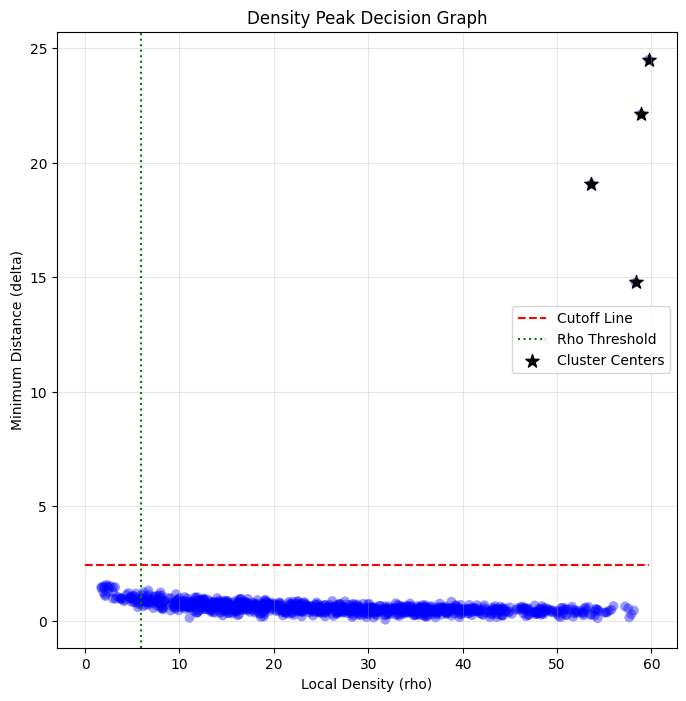

In [4]:
%matplotlib inline
fig1, ax1 = plot_decision_graph(model)
plt.show()

## 4. Visualize the Clusters

Our `plot_clusters` function automatically detects that the data is >3 dimensions. It will gracefully log a warning and plot the first 3 dimensions, ensuring we still get a 3D visualization without crashing.

Input data has 4 dimensions. Plotting only the first 3 dimensions.


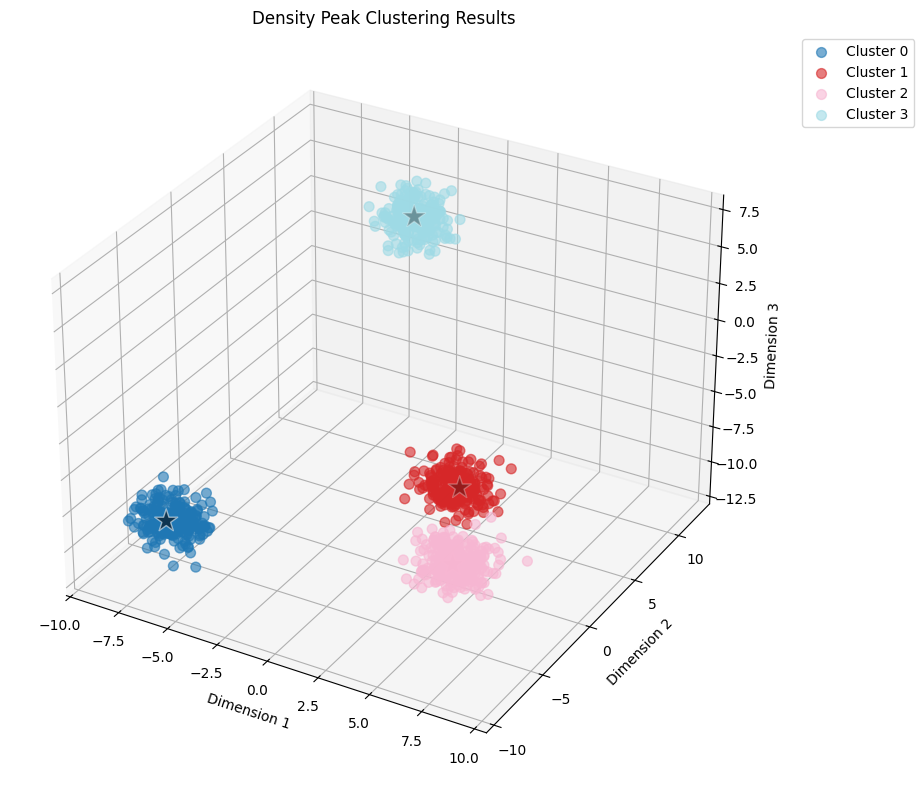

In [5]:
fig2, ax2 = plot_clusters(model, X)
plt.show()

## 5. Verify Clustering Accuracy

Even though we can only plot 3 dimensions, the clustering occurred in full 4D space. Let's use the Adjusted Rand Index (ARI) to prove the clustering perfectly matched the true synthetic labels.

In [6]:
ari = adjusted_rand_score(true_labels, labels)
print(f"Clustering Accuracy (Adjusted Rand Index): {ari:.3f}")

Clustering Accuracy (Adjusted Rand Index): 1.000
